In [1]:
with open("volume/info.txt") as f:
    lines = f.read().splitlines()
# 找到包含 'PARAVIEW DIMENSIONS' 后的三行并解析范围
dims = []
for l in lines:
    l = l.strip()
    if l.startswith("0 -"):
        lo,hi = map(int, l.split('-'))
        dims.append(hi - lo + 1)
nx, ny, nz = dims  # 注意顺序要确认（文件行顺序）

In [3]:
dims

[21, 59, 71]

/home/zchen/.conda/envs/nerf/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/zchen/.conda/envs/nerf/lib/python3.11/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


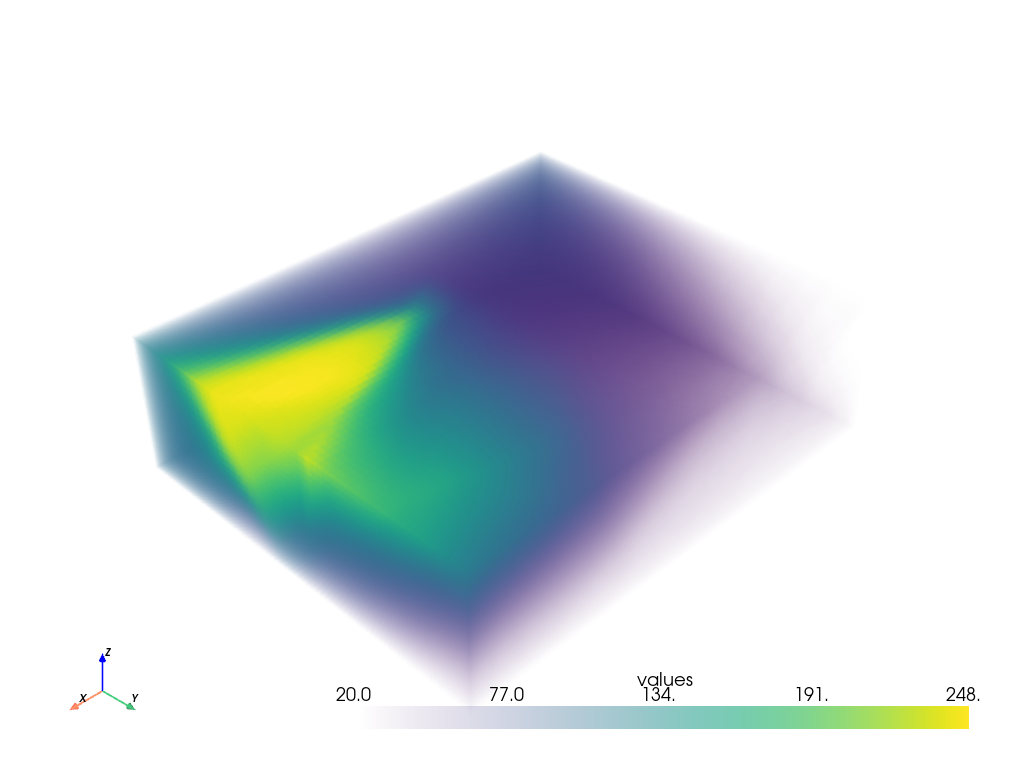

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

path = "/home/zchen/export-nerf-code/volume/volume.raw"
data = np.fromfile(path, dtype=np.uint8)

vol = data.reshape((nz, ny, nx))
# vol = data.reshape((nx, ny, nz))
grid = pv.wrap(vol)  # 创建 PyVista 网格对象
grid.plot(volume=True)  # 使用体渲染显示数据

In [9]:
import numpy as np
import pickle

pkl_path = "/home/zchen/export-nerf-code/datasets/baked/seinGrandeSphereValidNew.pkl"

try:
    # 如果文件是 numpy 存储，但包含 Python 对象，需要 allow_pickle=True
    data = np.load(pkl_path, allow_pickle=True)
    print("Loaded with numpy.load (allow_pickle=True)")
except Exception as e:
    # 回退到 pickle.load（常用于 .pkl）
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    print("Loaded with pickle.load")

print(type(data))
# 若需要查看更详细结构，可打印 repr(data) 或检查 keys/shape

Loaded with numpy.load (allow_pickle=True)
<class 'numpy.lib.npyio.NpzFile'>


In [17]:
import torch
dataset = torch.load("/home/zchen/export-nerf-code/datasets/baked/seinGrandeSphereValidNew.pkl",weights_only=False)["dataset"]

In [1]:
from pathlib import Path

data_path = Path("datasets/4-results-video-trans_56")

pic_paths = list(data_path.rglob("*scat_filtered_must.png"))

In [3]:
import shutil

import os

os.makedirs("datasets/simu_56/us", exist_ok=True)
for path in pic_paths:
    idx = str(path.parents[1]).split("_")[-1]
    shutil.copy(path, f"datasets/simu_56/us/us{idx}.jpg")


In [11]:
from pathlib import Path

json_path = Path("datasets/4-results-video-trans_56")

json_paths = sorted(list(json_path.rglob("*.json")), key=lambda p: int(str(p.parents[1]).split("_")[-1]))

In [ ]:
import json
from scipy.spatial.transform import Rotation as R
import numpy as np
from pathlib import Path


data_path = Path("datasets/4-results-video-trans_56")
save_path = Path("datasets/simu_56")


pic_paths = list(data_path.rglob("*scat_filtered_must.png"))

os.makedirs(f"{save_path}/us", exist_ok=True)
for path in pic_paths:
    idx = str(path.parents[1]).split("_")[-1]
    shutil.copy(path, f"{save_path}/us/us{idx}.jpg")


json_paths = sorted(list(data_path.rglob("*.json")), key=lambda p: int(str(p.parents[1]).split("_")[-1]))

position = np.empty((len(json_paths), 3))
rotation = np.empty((len(json_paths), 4))  # 四元数表示
width = 30
height = 20
for i, p in enumerate(json_paths):
    with open(p, "r") as f:
        data = json.load(f)
    position_x = data["AcquisitionZone"]["FinalPosition"]["x"]
    position_y = data["AcquisitionZone"]["FinalPosition"]["y"]
    position_z = data["AcquisitionZone"]["FinalPosition"]["z"]
    rotation_x = data["AcquisitionZone"]["Rotation"]["Axis"]["x"]
    rotation_y = data["AcquisitionZone"]["Rotation"]["Axis"]["y"]
    rotation_z = data["AcquisitionZone"]["Rotation"]["Axis"]["z"]
    angle = data["AcquisitionZone"]["Rotation"]["Angle"]
    
    r = R.from_rotvec(angle * np.array([rotation_x, rotation_y, rotation_z]), degrees=True)
    x, y, z, w = np.round(r.as_quat(), decimals=6)  # x, y, z, w

    position[i] = [position_x, position_y, position_z]
    rotation[i] = [w, x, y, z]  # 注意四元

max = position.max(axis=0)
min = position.min(axis=0)
size = max - min
with open(f"{save_path}/infos.dat", "w") as f:
        f.write(f"min({min[0]:.6f}, {min[1]:.6f}, {min[2]:.6f}) -> max({max[0]:.6f}, {max[1]:.6f}, {max[2]:.6f}) -> size({size[0]:.6f}, {size[1]:.6f}, {size[2]:.6f})\n")
        for i in range(len(json_paths)):
            f.write(f"{position[i, 0]:.6f} {position[i, 1]:.6f} {position[i, 2]:.6f} {rotation[i, 0]:.6f} {rotation[i, 1]:.6f} {rotation[i, 2]:.6f} {rotation[i, 3]:.6f} {width} {height}\n")
            
    